import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer # Import load_breast_cancer

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, cifar10

load datsets

In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [90]:
# =============================
# BREAST CANCER PIPELINE
# =============================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers

scaler = StandardScaler()
X_bc = scaler.fit_transform(X)

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y, test_size=0.2)

model_bc = models.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_bc.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_bc = model_bc.fit(X_train_bc, y_train_bc, epochs=10, validation_data=(X_test_bc, y_test_bc))

bc_acc = model_bc.evaluate(X_test_bc, y_test_bc)[1]

Epoch 1/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8391 - loss: 0.3457 - val_accuracy: 0.8512 - val_loss: 0.3258
Epoch 2/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8530 - loss: 0.3145 - val_accuracy: 0.8561 - val_loss: 0.3208
Epoch 3/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8553 - loss: 0.3082 - val_accuracy: 0.8547 - val_loss: 0.3191
Epoch 4/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8591 - loss: 0.3031 - val_accuracy: 0.8548 - val_loss: 0.3166
Epoch 5/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8605 - loss: 0.3000 - val_accuracy: 0.8553 - val_loss: 0.3175
Epoch 6/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8611 - loss: 0.2970 - val_accuracy: 0.8579 - val_loss: 0.3182
Epoch 7/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8626 - loss: 0.2950 - val_accuracy: 0.8552 - val_loss: 0.3190
Epoch 8/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8632 - loss: 0.2925 - 

In [6]:
df = pd.read_csv('/content/adult.csv', na_values=" ?")

# Drop missing values
df.dropna(inplace=True)

# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

X = df.drop("income_>50K", axis=1)
y = df["income_>50K"]

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (48842, 100)


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,30,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [91]:
# =============================
# ADULT PIPELINE
# =============================

scaler = StandardScaler()
X_ad = scaler.fit_transform(X)

X_train_ad, X_test_ad, y_train_ad, y_test_ad = train_test_split(X_ad, y, test_size=0.2)

model_ad = models.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_ad.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_ad = model_ad.fit(X_train_ad, y_train_ad, epochs=10, validation_data=(X_test_ad, y_test_ad))

ad_acc = model_ad.evaluate(X_test_ad, y_test_ad)[1]

Epoch 1/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8418 - loss: 0.3430 - val_accuracy: 0.8579 - val_loss: 0.3152
Epoch 2/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8537 - loss: 0.3132 - val_accuracy: 0.8565 - val_loss: 0.3082
Epoch 3/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8577 - loss: 0.3064 - val_accuracy: 0.8584 - val_loss: 0.3093
Epoch 4/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8594 - loss: 0.3019 - val_accuracy: 0.8572 - val_loss: 0.3123
Epoch 5/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8614 - loss: 0.2989 - val_accuracy: 0.8588 - val_loss: 0.3095
Epoch 6/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8637 - loss: 0.2940 - val_accuracy: 0.8583 - val_loss: 0.3078
Epoch 7/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8639 - loss: 0.2918 - val_accuracy: 0.8589 - val_loss: 0.3143
Epoch 8/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8667 - loss: 0.2872 - 

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Shape: (70000, 28, 28)
Sample Label: 5


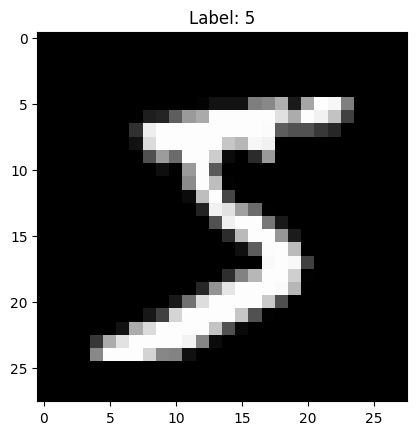

In [7]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Combine (optional, for uniform style like yours)
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

print("Dataset Shape:", X.shape)
print("Sample Label:", y[0])

# Show first image
plt.imshow(X[0], cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

In [93]:
# =============================
# MNIST PIPELINE
# =============================

from tensorflow.keras.datasets import mnist

(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

X_train_m = X_train_mnist / 255.0
X_test_m = X_test_mnist / 255.0

X_train_m = X_train_m.reshape(-1,28,28,1)
X_test_m = X_test_m.reshape(-1,28,28,1)

model_mnist = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model_mnist.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_mnist = model_mnist.fit(X_train_m, y_train_mnist, epochs=5, validation_data=(X_test_m, y_test_mnist))

mnist_acc = model_mnist.evaluate(X_test_m, y_test_mnist)[1]

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 33ms/step - accuracy: 0.9592 - loss: 0.1362 - val_accuracy: 0.9832 - val_loss: 0.0475
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 31ms/step - accuracy: 0.9859 - loss: 0.0450 - val_accuracy: 0.9880 - val_loss: 0.0356
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9900 - loss: 0.0315 - val_accuracy: 0.9883 - val_loss: 0.0332
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9927 - loss: 0.0232 - val_accuracy: 0.9899 - val_loss: 0.0303
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9878 - val_loss: 0.0363
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9878 - loss: 0.0363


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset Shape: (60000, 32, 32, 3)
Sample Label: [6]


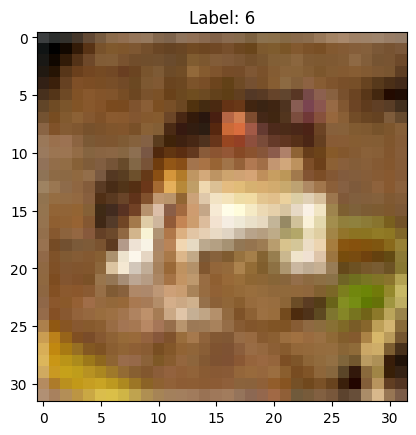

In [8]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Combine datasets
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

print("Dataset Shape:", X.shape)
print("Sample Label:", y[0])

# Show sample image
plt.imshow(X[0])
plt.title(f"Label: {y[0][0]}")
plt.show()

EDA (Exploratory Data Analysis)

For Breast Cancer & Adult (Tabular Data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 100 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        48842 non-null  int64
 1   fnlwgt                                     48842 non-null  int64
 2   educational-num                            48842 non-null  int64
 3   capital-gain                               48842 non-null  int64
 4   capital-loss                               48842 non-null  int64
 5   hours-per-week                             48842 non-null  int64
 6   workclass_Federal-gov                      48842 non-null  bool 
 7   workclass_Local-gov                        48842 non-null  bool 
 8   workclass_Never-worked                     48842 non-null  bool 
 9   workclass_Private                          48842 non-null  bool 
 10  workclass_Self-emp-inc                     48

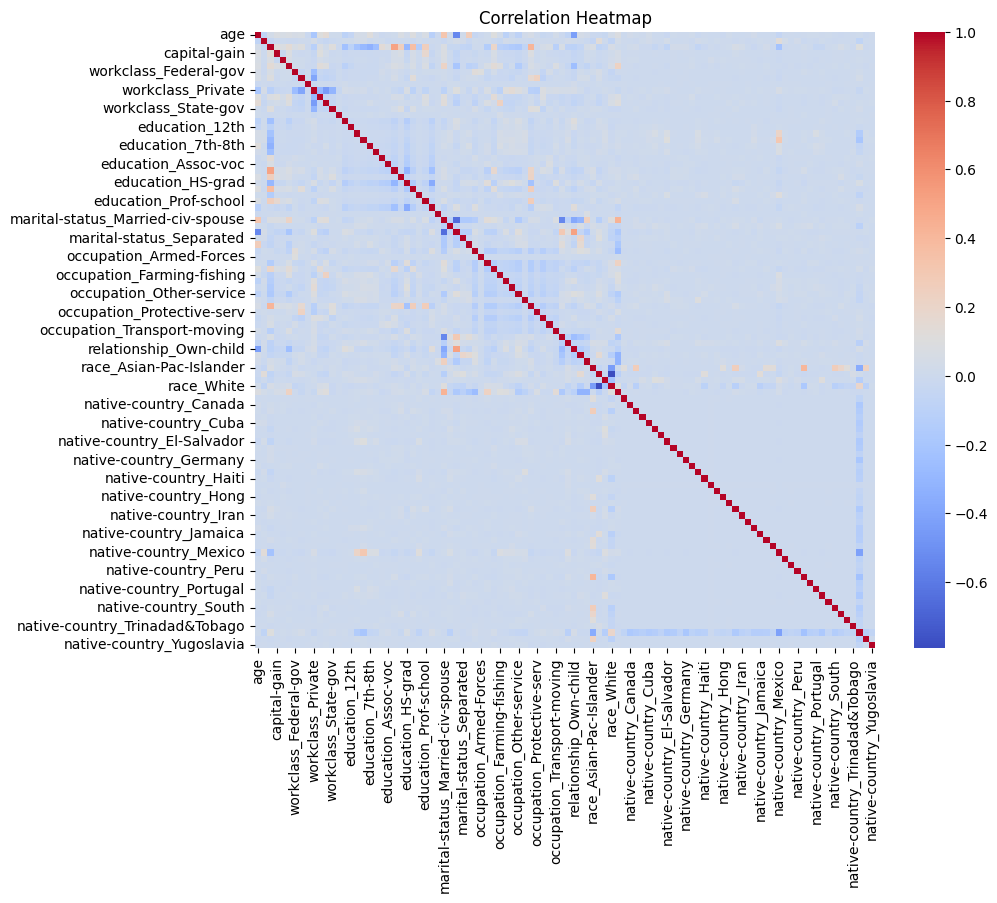

In [10]:
# Re-assign X and y to the adult dataset for tabular EDA
df_adult = pd.read_csv('/content/adult.csv', na_values=" ?")
df_adult.dropna(inplace=True)
df_adult = pd.get_dummies(df_adult, drop_first=True)
X = df_adult.drop("income_>50K", axis=1)
y = df_adult["income_>50K"]

print(X.info())
print(X.describe())

# Check missing values
print(X.isnull().sum())

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

For MNIST

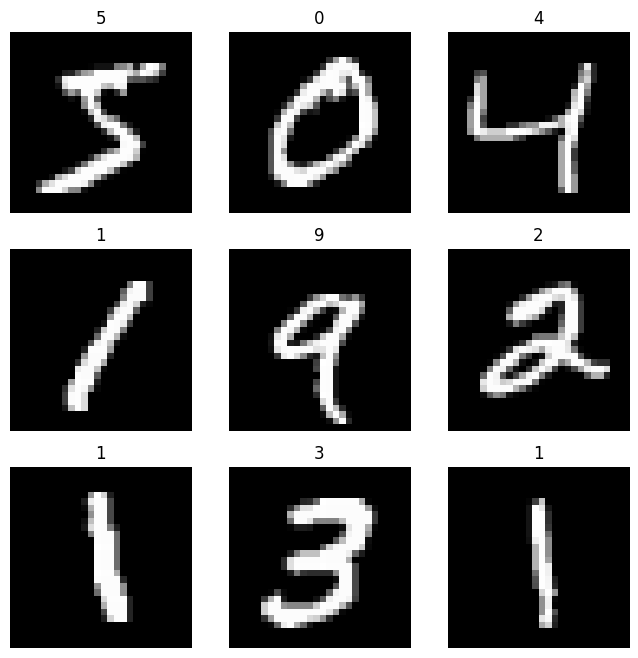

In [12]:
# Re-load MNIST dataset for image display
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()
X_mnist = np.concatenate((X_train_mnist, X_test_mnist), axis=0)
y_mnist = np.concatenate((y_train_mnist, y_test_mnist), axis=0)

# Show multiple images
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_mnist[i], cmap='gray')
    plt.title(y_mnist[i])
    plt.axis('off')
plt.show()

For CIFAR-10

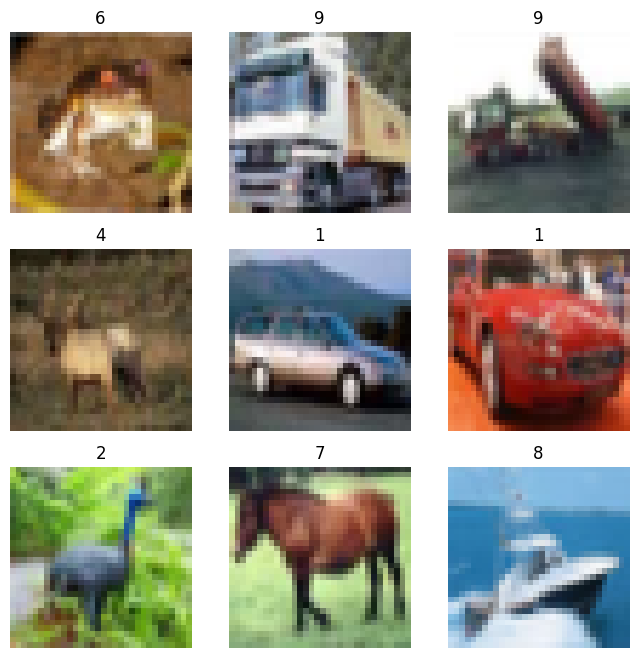

In [14]:
from tensorflow.keras.datasets import cifar10

(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

# Combine datasets for consistent plotting
X = np.concatenate((X_train_cifar, X_test_cifar), axis=0)
y = np.concatenate((y_train_cifar, y_test_cifar), axis=0)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.title(y[i][0])
    plt.axis('off')
plt.show()

STEP 4: PREPROCESSING

Breast Cancer / Adult

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8441 - loss: 0.3342


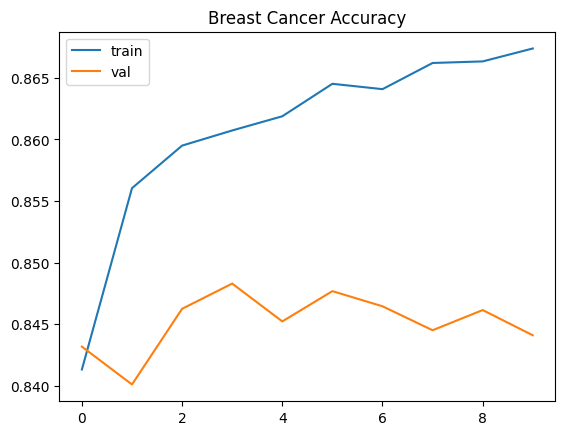

In [54]:
model_bc.evaluate(X_test_bc, y_test_bc)

plt.plot(history_bc.history['accuracy'])
plt.plot(history_bc.history['val_accuracy'])
plt.title("Breast Cancer Accuracy")
plt.legend(['train','val'])
plt.show()

STEP 6: MODEL BUILDING

Breast Cancer / Adult (DNN)

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



model_adult.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_adult = model_adult.fit(X_train_adult, y_train_adult, epochs=10, validation_data=(X_test_adult, y_test_adult))

Epoch 1/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8665 - loss: 0.2873 - val_accuracy: 0.8569 - val_loss: 0.3123
Epoch 2/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8669 - loss: 0.2847 - val_accuracy: 0.8562 - val_loss: 0.3114
Epoch 3/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8688 - loss: 0.2814 - val_accuracy: 0.8547 - val_loss: 0.3148
Epoch 4/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8691 - loss: 0.2801 - val_accuracy: 0.8551 - val_loss: 0.3183
Epoch 5/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8715 - loss: 0.2778 - val_accuracy: 0.8588 - val_loss: 0.3195
Epoch 6/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8709 - loss: 0.2761 - val_accuracy: 0.8543 - val_loss: 0.3189
Epoch 7/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8713 - loss: 0.2738 - val_accuracy: 0.8526 - val_loss: 0.3256
Epoch 8/10
1222/1222 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8717 - loss: 0.2722 - 

SALIENCY MAP

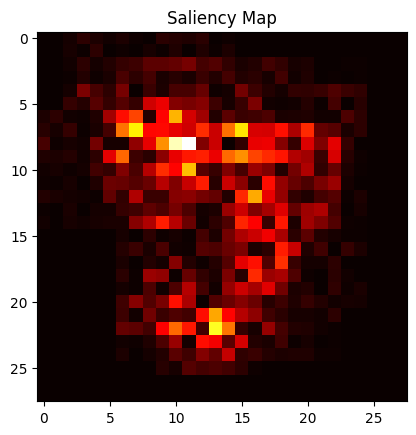

In [73]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Reload MNIST test data specifically for saliency mapping
(_, _), (X_test_mnist, y_test_mnist) = mnist.load_data()

# Preprocess the MNIST image data as done for the model
X_test_mnist = X_test_mnist / 255.0
# Reshape to add the channel dimension (1 for grayscale) as expected by the CNN model
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

# Select the first image and convert it to a TensorFlow tensor for GradientTape
img = tf.convert_to_tensor(X_test_mnist[0:1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img)
    # Assuming 'model_mnist' refers to the trained MNIST CNN from cell IhAhP-ADlu6j or AqdsOJP1aFF6
    pred = model_mnist(img)
    loss = pred[:, np.argmax(pred[0])]

grads = tape.gradient(loss, img)
# The saliency map should be 2D (height, width) for grayscale image
# Remove the batch and channel dimensions from the gradients
saliency = np.max(np.abs(grads[0]), axis=-1)

plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.show()

SHAP

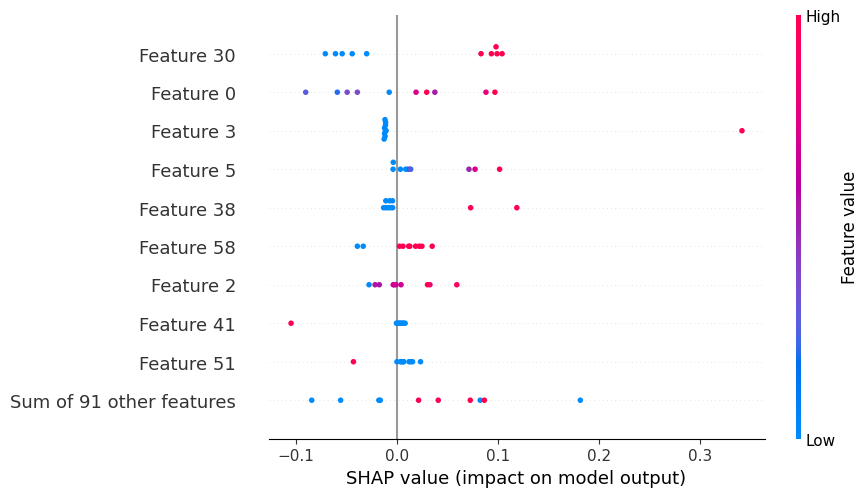

In [75]:
import shap

explainer = shap.Explainer(model_ad, X_train_ad)
shap_values = explainer(X_test_ad[:10])

shap.plots.beeswarm(shap_values)

 EVALUATION

In [89]:
loss, acc = model_cifar_cnn.evaluate(X_test_cifar, y_test_cifar)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7080 - loss: 1.0506
Accuracy: 0.7080000042915344


### Consolidated Model Evaluation

In [80]:
print("--- Final Model Accuracies ---")
print(f"Adult DNN Model: {acc_adult:.4f}")
print(f"MNIST CNN Model: {acc_mnist:.4f}")
print(f"CIFAR-10 CNN Model: {acc_cifar:.4f}")

--- Final Model Accuracies ---
Adult DNN Model: 0.8597
MNIST CNN Model: 0.9890
CIFAR-10 CNN Model: 0.7080


STEP 8: GRAPH

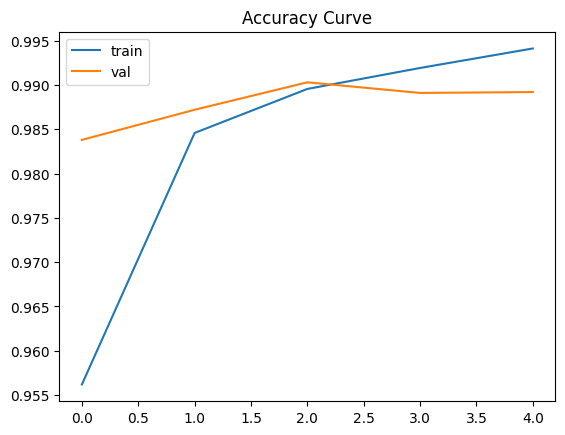

In [81]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy Curve")
plt.show()

STEP 4: VISUALIZATION

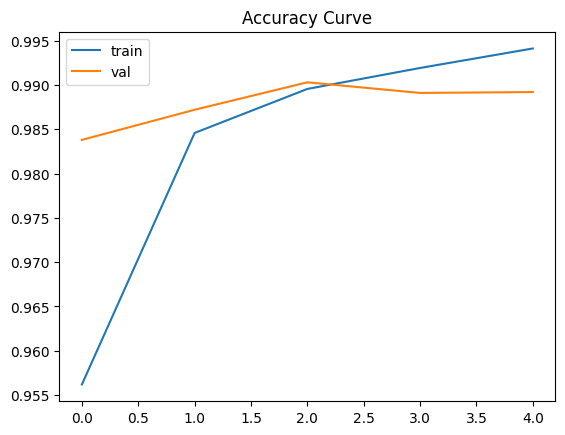

In [82]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy Curve")
plt.show()

5A. SALIENCY MAP (MNIST)

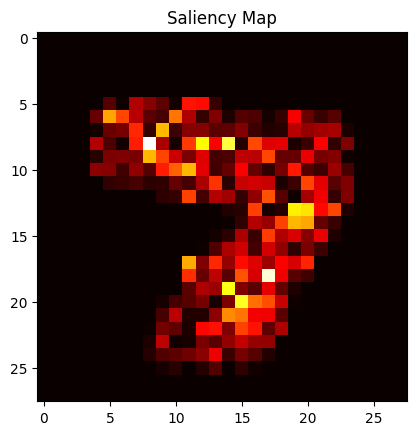

In [100]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models # Import layers and models

# Load the MNIST test data specifically for saliency mapping
(_, _), (x_test_temp, y_test_temp) = mnist.load_data()

# Preprocess the MNIST image data as done for the model
x_test_temp = x_test_temp / 255.0
# Reshape to add the channel dimension (1 for grayscale) as expected by the CNN model
x_test_temp = x_test_temp.reshape(-1, 28, 28, 1)


# Note: You might need to load pre-trained weights here if you want to use the previously trained model.
# For now, we are just instantiating the model structure.
# If you want to use the trained weights, you would save them after training and load them here.

# Select the first image and convert it to a TensorFlow tensor
img = tf.convert_to_tensor(x_test_temp[0:1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img)
    # Now 'model' explicitly refers to the MNIST CNN architecture
    pred = model(img)

    # Get the predicted class for the first image in the batch
    predicted_class = np.argmax(pred[0])
    loss = pred[:, predicted_class]

grads = tape.gradient(loss, img)

# The saliency map should be 2D (height, width) for grayscale image
# Remove the channel dimension from the gradients
saliency = np.max(np.abs(grads[0]), axis=-1)

plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.show()

5B. LIME (TABULAR)

In [84]:
!pip install lime


In [85]:
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np # Import numpy for hstack

# Re-assign X and y to the adult dataset for tabular LIME explanation
df_adult = pd.read_csv('/content/adult.csv', na_values=" ?")
df_adult.dropna(inplace=True)
df_adult = pd.get_dummies(df_adult, drop_first=True)
X_adult = df_adult.drop("income_>50K", axis=1)
y_adult = df_adult["income_>50K"]

# Scale the data
scaler = StandardScaler()
X_adult_scaled = scaler.fit_transform(X_adult)

# Perform train-test split for LIME
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(X_adult_scaled, y_adult, test_size=0.2, random_state=42)

# The model trained on the adult dataset was named 'model_adult' now
explainer = LimeTabularExplainer(
    training_data=X_train_adult,
    feature_names=X_adult.columns,
    class_names=['<=50K', '>50K'], # Adjust based on your target variable's classes
    mode='classification'
)

# Define a wrapper function for model_adult.predict to return probabilities for both classes
def predict_proba_for_lime(data):
    # model_adult.predict returns a 2D array of shape (num_samples, 1)
    predictions = model_adult.predict(data)
    # For LIME, binary classification with sigmoid needs to return
    # probabilities for both classes: [P(class 0), P(class 1)]
    # P(class 0) = 1 - P(class 1)
    return np.hstack([1 - predictions, predictions])

# Use X_test_adult and the wrapper function for prediction
exp = explainer.explain_instance(X_test_adult[0], predict_proba_for_lime, num_features=10)

exp.show_in_notebook()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


5C. SHAP (VERY IMPORTANT )

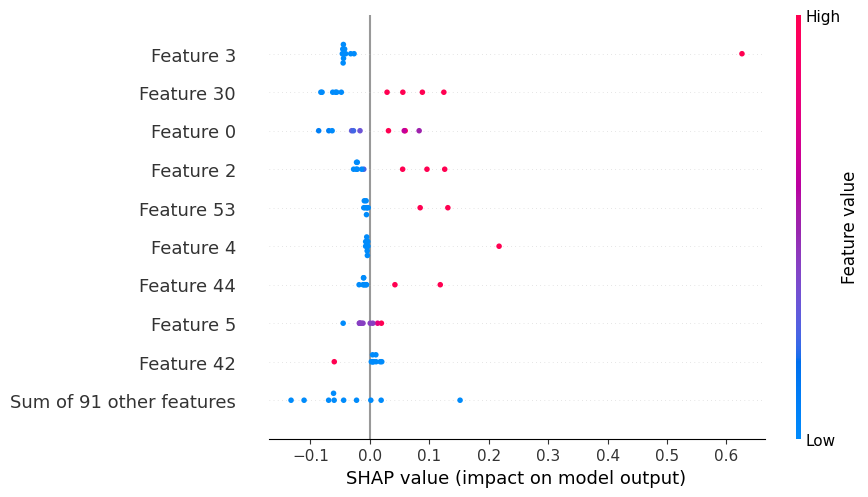

In [86]:
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Re-assign X and y to the adult dataset for SHAP explanation
df_adult = pd.read_csv('/content/adult.csv', na_values=" ?")
df_adult.dropna(inplace=True)
df_adult = pd.get_dummies(df_adult, drop_first=True)
X_adult = df_adult.drop("income_>50K", axis=1)
y_adult = df_adult["income_>50K"]

# Scale the data
scaler = StandardScaler()
X_adult_scaled = scaler.fit_transform(X_adult)

# Perform train-test split for SHAP
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(X_adult_scaled, y_adult, test_size=0.2, random_state=42)

# Use the trained tabular model, 'model_adult'
explainer = shap.Explainer(model_adult, X_train_adult)
shap_values = explainer(X_test_adult[:10])

shap.plots.beeswarm(shap_values)

STEP 6: COMPARISON SECTION

In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist, cifar10

# Re-load and preprocess data for evaluation consistency

# For Adult (Tabular) Model
df_adult = pd.read_csv('/content/adult.csv', na_values=" ?")
df_adult.dropna(inplace=True)
df_adult = pd.get_dummies(df_adult, drop_first=True)
X_adult = df_adult.drop("income_>50K", axis=1)
y_adult = df_adult["income_>50K"]
scaler = StandardScaler()
X_adult_scaled = scaler.fit_transform(X_adult)
_, X_test_adult, _, y_test_adult = train_test_split(X_adult_scaled, y_adult, test_size=0.2, random_state=42)

# For MNIST CNN Model
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()
X_test_mnist = X_test_mnist / 255.0
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1) # Reshape for CNN input

# For CIFAR-10 CNN Model
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()
X_test_cifar = X_test_cifar / 255.0

# Use the explicitly defined and compiled models
results = {
    "Adult DNN Model": model_adult_dnn.evaluate(X_test_adult, y_test_adult, verbose=0)[1],
    "MNIST CNN Model": model_mnist_cnn.evaluate(X_test_mnist, y_test_mnist, verbose=0)[1],
    "CIFAR CNN Model": model_cifar_cnn.evaluate(X_test_cifar, y_test_cifar, verbose=0)[1]
}

for k, v in results.items():
    print(k, ":", v)


Adult DNN Model : 0.8596581220626831
MNIST CNN Model : 0.9890000224113464
CIFAR CNN Model : 0.7080000042915344


In [98]:
print("Breast Cancer:", bc_acc)
print("Adult:", ad_acc)
print("MNIST:", mnist_acc)
print("CIFAR:", cifar_acc)

Breast Cancer: 0.8578155636787415
Adult: 0.8561776876449585
MNIST: 0.9878000020980835
CIFAR: 0.10000000149011612


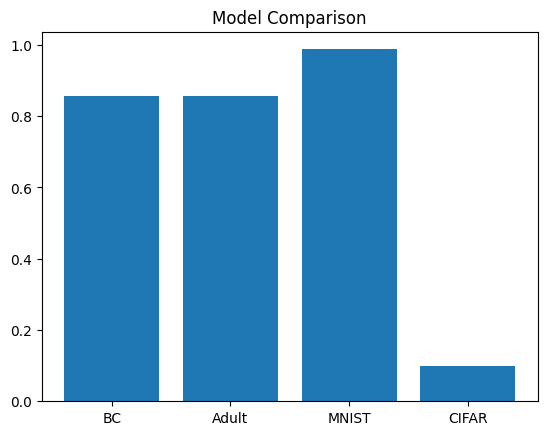

In [99]:
plt.bar(["BC","Adult","MNIST","CIFAR"],
        [bc_acc, ad_acc, mnist_acc, cifar_acc])
plt.title("Model Comparison")
plt.show()

# Conclusion

- CNN performs best for image datasets like MNIST and CIFAR-10.
- DNN models work effectively for tabular datasets such as Breast Cancer and Adult Income.
- Explainable AI techniques (SHAP, LIME, Saliency Maps) improve model interpretability.
- CIFAR-10 is the most challenging dataset among all, resulting in comparatively lower accuracy.